# Fast Segment Anything Model (FastSAM)

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/fast-sam/

In [5]:
!nvidia-smi

Fri Nov 21 21:16:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 32%   48C    P5             36W /  250W |    8712MiB /  11264MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download test data

In [4]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

### FastSAM Comparison vs YOLO

In [1]:
from ultralytics import ASSETS, SAM, YOLO, FastSAM

# Profile SAM2-t, SAM2-b, SAM-b, MobileSAM
for file in ["sam_b.pt", "sam2_b.pt", "sam2_t.pt", "mobile_sam.pt"]:
    model = SAM("./temp_model/" + file)
    model.info()
    model(ASSETS)

# Profile FastSAM-s
model = FastSAM("./temp_model/FastSAM-s.pt")
model.info()
model(ASSETS)

# Profile YOLO models
for file_name in ["yolov8n-seg.pt", "yolo11n-seg.pt"]:
    model = YOLO("./temp_model/" + file_name)
    model.info()
    model(ASSETS)

Model summary: 173 layers, 93,735,472 parameters, 93,735,472 gradients

image 1/2 /home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/ultralytics/assets/bus.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 1 60, 1 61, 1 62, 1 63, 1 64, 1 65, 1 66, 1 67, 1 68, 1 69, 1 70, 1 71, 1 72, 1 73, 5517.9ms
image 2/2 /home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/ultralytics/assets/zidane.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 4540.3ms
Speed: 9.0ms preprocess, 5029.1ms inference, 1.9ms postprocess per image at shape (1,

### Mobile-SAM :: Point prompt


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 1024x768 95 objects, 220.9ms
Speed: 5.9ms preprocess, 220.9ms inference, 243.5ms postprocess per image at shape (1, 3, 1024, 768)


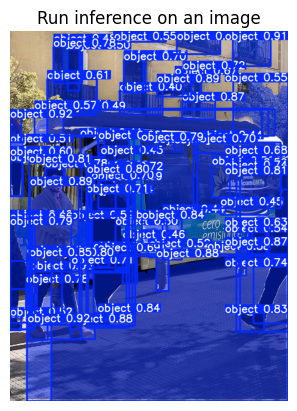


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 1 object, 109.9ms
Speed: 1.6ms preprocess, 109.9ms inference, 537.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 3 objects, 105.9ms
Speed: 1.7ms preprocess, 105.9ms inference, 390.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 1 object, 80.3ms
Speed: 1.5ms preprocess, 80.3ms inference, 6174.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x480 5 objects, 106.4ms
Speed: 1.6ms preprocess, 106.4ms inference, 3788.2ms postprocess per image at shape (1, 3, 640, 480)


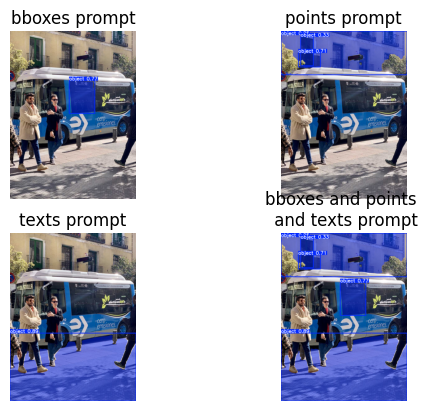

In [12]:
from ultralytics import FastSAM
import matplotlib.pyplot as plt
import cv2


# Define an inference source
source = "./temp_assets/bus.jpg"


# Create a FastSAM model
model = FastSAM("./temp_model/FastSAM-s.pt")  # or FastSAM-x.pt

# Run inference on an image
everything_results = model(source, device="cpu", retina_masks=True, imgsz=1024, conf=0.4, iou=0.9)
bgr_image = everything_results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()

# source = "https://github.com/CASIA-LMC-Lab/FastSAM/blob/main/examples/dogs.jpg?raw=true"

fig, axs = plt.subplots(2, 2)
# Run inference with bboxes prompt
results = model(source, bboxes=[439, 437, 524, 709])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 0].imshow(rgb_image)
axs[0, 0].set_axis_off()
axs[0, 0].set_title("bboxes prompt")

# Run inference with points prompt
results = model(source, points=[[200, 200]], labels=[1])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 1].imshow(rgb_image)
axs[0, 1].set_axis_off()
axs[0, 1].set_title("points prompt")

# Run inference with texts prompt
results = model(source, texts="a photo of a dog")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 0].imshow(rgb_image)
axs[1, 0].set_axis_off()
axs[1, 0].set_title("texts prompt")

# Run inference with bboxes and points and texts prompt at the same time
results = model(source, bboxes=[439, 437, 524, 709], points=[[200, 200]], labels=[1], texts="a photo of a dog")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 1].imshow(rgb_image)
axs[1, 1].set_axis_off()
axs[1, 1].set_title("bboxes and points \n and texts prompt")

plt.show()

### FastSAMPredictor example


Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 1024x1024 118 objects, 15.8ms
Speed: 3.5ms preprocess, 15.8ms inference, 9.5ms postprocess per image at shape (1, 3, 1024, 1024)


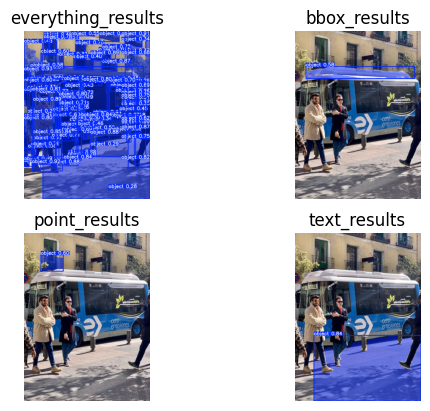

In [13]:
from ultralytics.models.fastsam import FastSAMPredictor

# Create FastSAMPredictor
overrides = dict(conf=0.25, task="segment", mode="predict", model="./temp_model/FastSAM-s.pt", save=False, imgsz=1024)
predictor = FastSAMPredictor(overrides=overrides)

fig, axs = plt.subplots(2, 2)
# Segment everything
source = "./temp_assets/bus.jpg"
everything_results = predictor(source)
bgr_image = everything_results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 0].imshow(rgb_image)
axs[0, 0].set_axis_off()
axs[0, 0].set_title("everything_results")

# Prompt inference
bbox_results = predictor.prompt(everything_results, bboxes=[[200, 200, 300, 300]])
bgr_image = bbox_results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 1].imshow(rgb_image)
axs[0, 1].set_axis_off()
axs[0, 1].set_title("bbox_results")

point_results = predictor.prompt(everything_results, points=[200, 200])
bgr_image = point_results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 0].imshow(rgb_image)
axs[1, 0].set_axis_off()
axs[1, 0].set_title("point_results")

text_results = predictor.prompt(everything_results, texts="a photo of a dog")
bgr_image = text_results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 1].imshow(rgb_image)
axs[1, 1].set_axis_off()
axs[1, 1].set_title("text_results")

plt.show()